# Nhóm 8 - Demo
- Hồ Hữu Tây
- Lê Thiên Quân
- Phạm Ngọc Thọ
- Dương Hoàng Việt

# Chapter 13 Demo — RNN/LSTM Sentiment Classification

**Bài toán:** phân loại một đoạn review là **positive** hoặc **negative**.





## Install & import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q datasets scikit-learn

import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## Load IMDb dataset online

In [3]:
# IMDb sentiment dataset
# label 0 = negative, label 1 = positive
raw_ds = load_dataset("imdb")

print(raw_ds)
print(raw_ds["train"][0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

## Split train / validation / test

In [4]:
# IMDb có sẵn train/test.
# Ta tách train thành train/validation.
split_ds = raw_ds["train"].train_test_split(
    test_size=0.15,
    seed=SEED,
    stratify_by_column="label",
)

train_df = split_ds["train"].to_pandas()
val_df = split_ds["test"].to_pandas()
test_df = raw_ds["test"].to_pandas()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

display(train_df.head())


Train: 21250
Validation: 3750
Test: 25000


,text,label
0,I loathed this film. The original Phantasm had...,0
1,Pearl S.Buck was a brilliant author that was a...,1
2,"Really, I think this movie is more an example ...",1
3,I will admit that I did not give this movie mu...,0
4,I read the novel some years ago and I liked it...,0


## Text preprocessing

In [5]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)      # IMDb hay có tag HTML <br />
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["text"].apply(clean_text)

display(train_df[["text", "clean_text", "label"]].head(3))


,text,clean_text,label
0,I loathed this film. The original Phantasm had...,i loathed this film the original phantasm had ...,0
1,Pearl S.Buck was a brilliant author that was a...,pearl s buck was a brilliant author that was a...,1
2,"Really, I think this movie is more an example ...",really i think this movie is more an example o...,1


Train used: 12000
Validation used: 3000
Test used: 3000


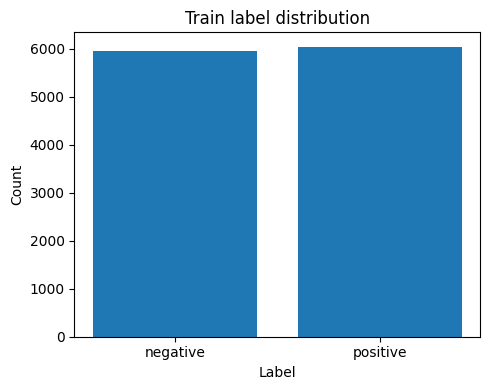

In [6]:
USE_SUBSET = True

MAX_TRAIN = 12000
MAX_VAL = 3000
MAX_TEST = 3000

if USE_SUBSET:
    train_df = train_df.sample(n=min(MAX_TRAIN, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(n=min(MAX_VAL, len(val_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(n=min(MAX_TEST, len(test_df)), random_state=SEED).reset_index(drop=True)

print("Train used:", len(train_df))
print("Validation used:", len(val_df))
print("Test used:", len(test_df))

label_names = {0: "negative", 1: "positive"}

label_count = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar([label_names[i] for i in label_count.index], label_count.values)
plt.title("Train label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Build vocabulary

In [7]:
MAX_VOCAB_SIZE = 30000
MAX_LEN = 256

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()

for text in train_df["clean_text"]:
    counter.update(tokenize(text)[:MAX_LEN])

word2id = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for word, freq in counter.most_common(MAX_VOCAB_SIZE):
    if word not in word2id:
        word2id[word] = len(word2id)

id2word = {i: w for w, i in word2id.items()}

print("Vocab size:", len(word2id))
print("Most common words:")
print(counter.most_common(20))


Vocab size: 30002
Most common words:
[('the', 123105), ('a', 60667), ('and', 60017), ('of', 53176), ('to', 48915), ('is', 39940), ('in', 33927), ('i', 31414), ('it', 30209), ('this', 30163), ('that', 25318), ('was', 19001), ('movie', 17858), ('as', 16783), ('for', 16005), ('with', 15962), ('but', 15685), ('film', 14850), ('on', 12562), ('not', 11363)]


## Dataset & DataLoader

In [8]:
def encode_text(text):
    tokens = tokenize(text)[:MAX_LEN]
    ids = [word2id.get(tok, word2id[UNK_TOKEN]) for tok in tokens]

    if len(ids) == 0:
        ids = [word2id[UNK_TOKEN]]

    return ids

class SentimentDataset(Dataset):
    def __init__(self, df):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx])
        label = self.labels[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    input_ids, labels = zip(*batch)

    lengths = torch.tensor([len(x) for x in input_ids], dtype=torch.long)
    max_len = int(lengths.max())

    padded = torch.zeros(len(batch), max_len, dtype=torch.long)

    for i, ids in enumerate(input_ids):
        padded[i, :len(ids)] = ids

    labels = torch.stack(labels)
    return padded, lengths, labels

BATCH_SIZE = 64

train_loader = DataLoader(
    SentimentDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    SentimentDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    SentimentDataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

batch = next(iter(train_loader))
print("input_ids:", batch[0].shape)
print("lengths:", batch[1].shape)
print("labels:", batch[2].shape)


input_ids: torch.Size([64, 256])
lengths: torch.Size([64])
labels: torch.Size([64])


## Build model: RNN / BiLSTM classifier

Với **sequence classification**, ta đọc văn bản như một chuỗi token, lấy hidden representation của chuỗi rồi đưa qua classifier softmax.

Ở đây dùng:
- `SimpleRNNClassifier`: baseline đúng kiến trúc RNN cơ bản.
- `BiLSTMClassifier`: model chính, dùng LSTM hai chiều để khai thác cả ngữ cảnh trái và phải.


In [9]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=256,
        num_classes=2,
        rnn_type="lstm",
        bidirectional=True,
        dropout=0.3,
        pad_idx=0,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx,
        )

        self.rnn_type = rnn_type
        self.bidirectional = bidirectional

        if rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                bidirectional=bidirectional,
            )
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError("rnn_type must be 'rnn' or 'lstm'")

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.dropout(self.embedding(input_ids))

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        if self.rnn_type == "lstm":
            _, (h_n, _) = self.rnn(packed)
        else:
            _, h_n = self.rnn(packed)

        if self.bidirectional:
            # h_n[-2] = final forward hidden
            # h_n[-1] = final backward hidden
            final_hidden = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            final_hidden = h_n[-1]

        final_hidden = self.dropout(final_hidden)
        logits = self.classifier(final_hidden)
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

simple_rnn = RNNClassifier(
    vocab_size=len(word2id),
    rnn_type="rnn",
    bidirectional=False,
    pad_idx=word2id[PAD_TOKEN],
).to(device)

bilstm = RNNClassifier(
    vocab_size=len(word2id),
    rnn_type="lstm",
    bidirectional=True,
    pad_idx=word2id[PAD_TOKEN],
).to(device)

print(simple_rnn)
print("Simple RNN params:", count_parameters(simple_rnn))

print(bilstm)
print("BiLSTM params:", count_parameters(bilstm))


RNNClassifier(
  (embedding): Embedding(30002, 256, padding_idx=0)
  (rnn): RNN(256, 256, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)
Simple RNN params: 7812610
RNNClassifier(
  (embedding): Embedding(30002, 256, padding_idx=0)
  (rnn): LSTM(256, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=2, bias=True)
)
BiLSTM params: 8734210


## Train / evaluate functions

In [10]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    metrics = {
        "loss": total_loss / max(1, len(loader)),
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
    }

    return metrics, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs=3, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss = 0.0
        train_preds = []
        train_labels = []

        for input_ids, lengths, labels in train_loader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.detach().cpu().numpy().tolist())
            train_labels.extend(labels.detach().cpu().numpy().tolist())

        train_metrics = {
            "loss": train_loss / max(1, len(train_loader)),
            "accuracy": accuracy_score(train_labels, train_preds),
            "recall": recall_score(train_labels, train_preds, zero_division=0),
            "f1": f1_score(train_labels, train_preds, zero_division=0),
        }

        val_metrics, _, _ = evaluate(model, val_loader)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
        }

        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_acc={row['val_accuracy']:.4f} | "
            f"val_recall={row['val_recall']:.4f} | "
            f"val_f1={row['val_f1']:.4f}"
        )

    return pd.DataFrame(history)


## Train models

In [11]:
print("Training Simple RNN")
rnn_history = train_model(
    simple_rnn,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
)

print("\nTraining BiLSTM")
bilstm_history = train_model(
    bilstm,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
)

display(rnn_history)
display(bilstm_history)


Training Simple RNN
Epoch 01 | train_loss=0.6963 | val_loss=0.6460 | val_acc=0.6407 | val_recall=0.6725 | val_f1=0.6479
Epoch 02 | train_loss=0.6449 | val_loss=0.6921 | val_acc=0.6060 | val_recall=0.5180 | val_f1=0.5638
Epoch 03 | train_loss=0.6098 | val_loss=0.6463 | val_acc=0.6347 | val_recall=0.6820 | val_f1=0.6474
Epoch 04 | train_loss=0.6023 | val_loss=0.5997 | val_acc=0.6990 | val_recall=0.7451 | val_f1=0.7088
Epoch 05 | train_loss=0.5568 | val_loss=0.5882 | val_acc=0.7147 | val_recall=0.7003 | val_f1=0.7070
Epoch 06 | train_loss=0.5129 | val_loss=0.5954 | val_acc=0.6950 | val_recall=0.7410 | val_f1=0.7049
Epoch 07 | train_loss=0.4737 | val_loss=0.5911 | val_acc=0.7313 | val_recall=0.6129 | val_f1=0.6917
Epoch 08 | train_loss=0.4330 | val_loss=0.6497 | val_acc=0.7403 | val_recall=0.5980 | val_f1=0.6937
Epoch 09 | train_loss=0.3898 | val_loss=0.6147 | val_acc=0.7643 | val_recall=0.7058 | val_f1=0.7465
Epoch 10 | train_loss=0.3765 | val_loss=0.6676 | val_acc=0.7160 | val_recall=0.7

,epoch,train_loss,train_accuracy,train_recall,train_f1,val_loss,val_accuracy,val_recall,val_f1
0,1,0.696346,0.549417,0.567550,0.559080,0.645996,0.640667,0.672542,0.647943
1,2,0.644910,0.637667,0.650497,0.643782,0.692148,0.606000,0.517966,0.563838
2,3,0.609776,0.672833,0.677815,0.675912,0.646281,0.634667,0.682034,0.647362
3,4,0.602285,0.676500,0.707119,0.687540,0.599692,0.699000,0.745085,0.708804
4,5,0.556786,0.718667,0.723510,0.721360,0.588196,0.714667,0.700339,0.707050
5,6,0.512865,0.753583,0.760430,0.756485,0.595362,0.695000,0.741017,0.704934
6,7,0.473668,0.780833,0.791225,0.784214,0.591132,0.731333,0.612881,0.691660
7,8,0.433018,0.806167,0.808113,0.807578,0.649727,0.740333,0.597966,0.693669
8,9,0.389770,0.831917,0.835927,0.833512,0.614746,0.764333,0.705763,0.746504
9,10,0.376463,0.840750,0.833278,0.840444,0.667611,0.716000,0.711864,0.711382


,epoch,train_loss,train_accuracy,train_recall,train_f1,val_loss,val_accuracy,val_recall,val_f1
0,1,0.645244,0.618750,0.643543,0.629525,0.587018,0.682667,0.483390,0.599664
1,2,0.524458,0.742333,0.732119,0.740952,0.588343,0.684000,0.908475,0.738699
2,3,0.408051,0.811417,0.819868,0.814005,0.493346,0.784333,0.759322,0.775892
3,4,0.292204,0.876083,0.876656,0.876873,0.469633,0.826667,0.774915,0.814683
4,5,0.213456,0.915583,0.918046,0.916302,0.450018,0.833667,0.842712,0.832831
5,6,0.151801,0.941083,0.943874,0.941614,0.507606,0.843667,0.829831,0.839218
6,7,0.101982,0.963083,0.962583,0.963300,0.601037,0.845333,0.815593,0.838328
7,8,0.073201,0.973583,0.973013,0.973739,0.626784,0.829667,0.789153,0.820007
8,9,0.052838,0.982417,0.981788,0.982520,0.582427,0.835000,0.815593,0.829369
9,10,0.045615,0.983667,0.984603,0.983788,0.754301,0.841667,0.791864,0.831021


## Plot loss / accuracy / recall / F1

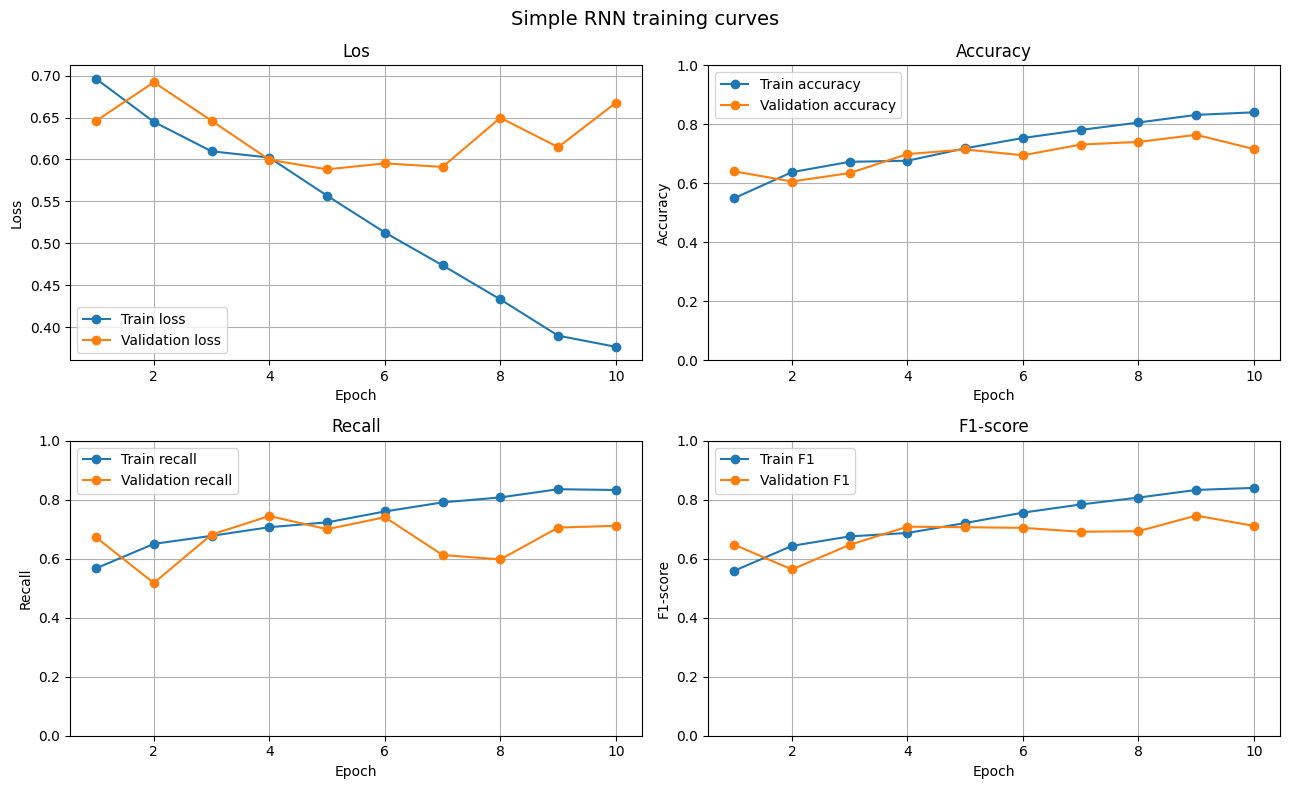

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(
    rnn_history["epoch"],
    rnn_history["train_loss"],
    marker="o",
    label="Train loss"
)
axes[0, 0].plot(
    rnn_history["epoch"],
    rnn_history["val_loss"],
    marker="o",
    label="Validation loss"
)
axes[0, 0].set_title("Los")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(
    rnn_history["epoch"],
    rnn_history["train_accuracy"],
    marker="o",
    label="Train accuracy"
)
axes[0, 1].plot(
    rnn_history["epoch"],
    rnn_history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(
    rnn_history["epoch"],
    rnn_history["train_recall"],
    marker="o",
    label="Train recall"
)
axes[1, 0].plot(
    rnn_history["epoch"],
    rnn_history["val_recall"],
    marker="o",
    label="Validation recall"
)
axes[1, 0].set_title("Recall")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(
    rnn_history["epoch"],
    rnn_history["train_f1"],
    marker="o",
    label="Train F1"
)
axes[1, 1].plot(
    rnn_history["epoch"],
    rnn_history["val_f1"],
    marker="o",
    label="Validation F1"
)
axes[1, 1].set_title("F1-score")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("F1-score")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(True)

fig.suptitle("Simple RNN training curves", fontsize=14)
plt.tight_layout()
plt.show()

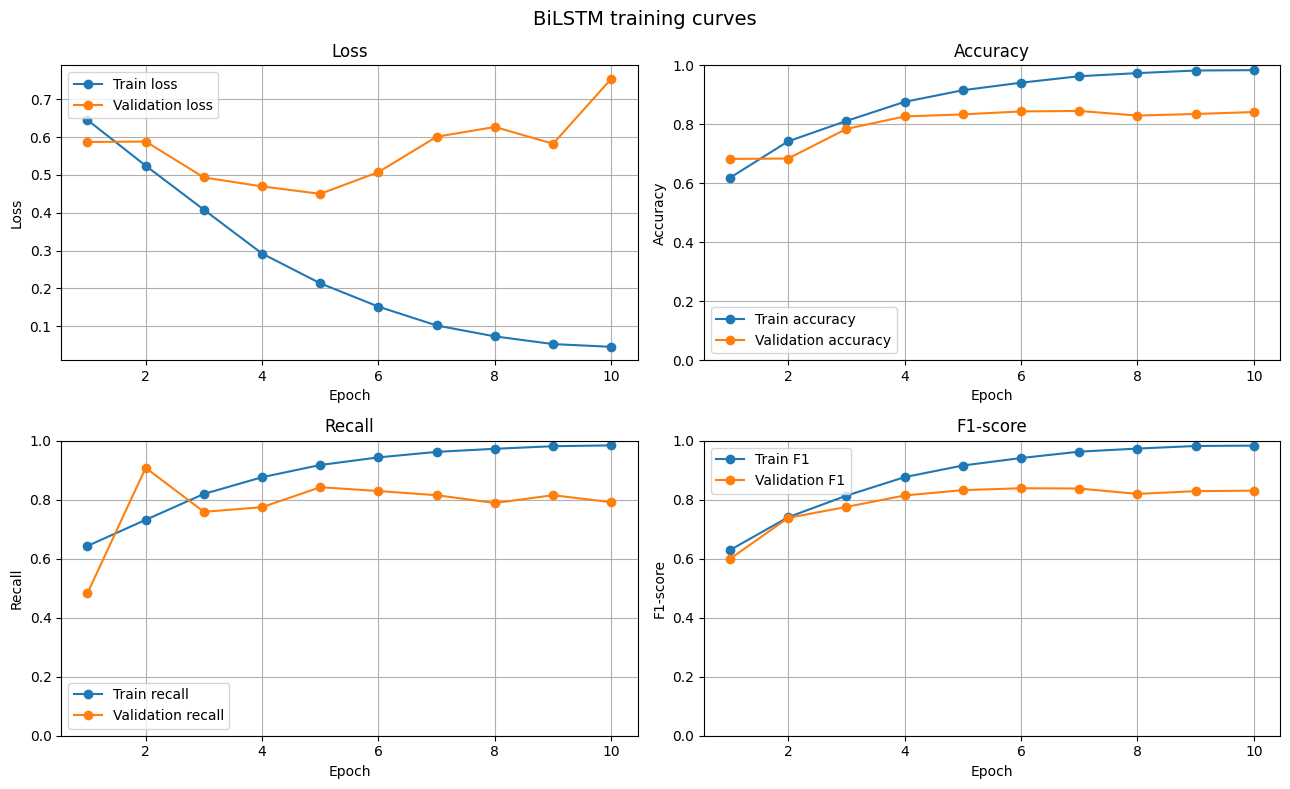

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(
    bilstm_history["epoch"],
    bilstm_history["train_loss"],
    marker="o",
    label="Train loss"
)
axes[0, 0].plot(
    bilstm_history["epoch"],
    bilstm_history["val_loss"],
    marker="o",
    label="Validation loss"
)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(
    bilstm_history["epoch"],
    bilstm_history["train_accuracy"],
    marker="o",
    label="Train accuracy"
)
axes[0, 1].plot(
    bilstm_history["epoch"],
    bilstm_history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(
    bilstm_history["epoch"],
    bilstm_history["train_recall"],
    marker="o",
    label="Train recall"
)
axes[1, 0].plot(
    bilstm_history["epoch"],
    bilstm_history["val_recall"],
    marker="o",
    label="Validation recall"
)
axes[1, 0].set_title("Recall")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(
    bilstm_history["epoch"],
    bilstm_history["train_f1"],
    marker="o",
    label="Train F1"
)
axes[1, 1].plot(
    bilstm_history["epoch"],
    bilstm_history["val_f1"],
    marker="o",
    label="Validation F1"
)
axes[1, 1].set_title("F1-score")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("F1-score")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(True)

fig.suptitle("BiLSTM training curves", fontsize=14)
plt.tight_layout()
plt.show()

## Evaluate trên validation và test

In [14]:
rnn_val_metrics, _, _ = evaluate(simple_rnn, val_loader)
rnn_test_metrics, _, _ = evaluate(simple_rnn, test_loader)

bilstm_val_metrics, val_preds, val_labels = evaluate(bilstm, val_loader)
bilstm_test_metrics, test_preds, test_labels = evaluate(bilstm, test_loader)

results_df = pd.DataFrame([
    {"model": "Simple RNN", "split": "validation", **rnn_val_metrics},
    {"model": "Simple RNN", "split": "test", **rnn_test_metrics},
    {"model": "BiLSTM", "split": "validation", **bilstm_val_metrics},
    {"model": "BiLSTM", "split": "test", **bilstm_test_metrics},
])

display(results_df)

print("BiLSTM classification report on test:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["negative", "positive"],
    digits=4,
))


,model,split,loss,accuracy,precision,recall,f1
0,Simple RNN,validation,0.667611,0.716000,0.710900,0.711864,0.711382
1,Simple RNN,test,0.658654,0.708667,0.687459,0.724567,0.705526
2,BiLSTM,validation,0.754301,0.841667,0.874251,0.791864,0.831021
3,BiLSTM,test,0.770696,0.839333,0.868966,0.784775,0.824727


BiLSTM classification report on test:
              precision    recall  f1-score   support

    negative     0.8165    0.8900    0.8517      1555
    positive     0.8690    0.7848    0.8247      1445

    accuracy                         0.8393      3000
   macro avg     0.8427    0.8374    0.8382      3000
weighted avg     0.8418    0.8393    0.8387      3000



## Plot final validation/test metrics

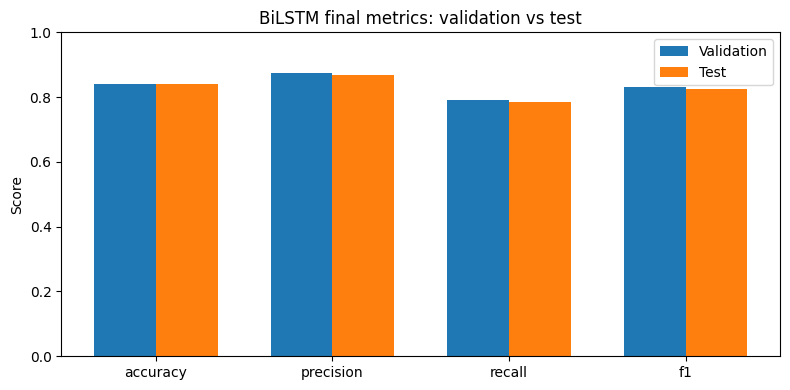

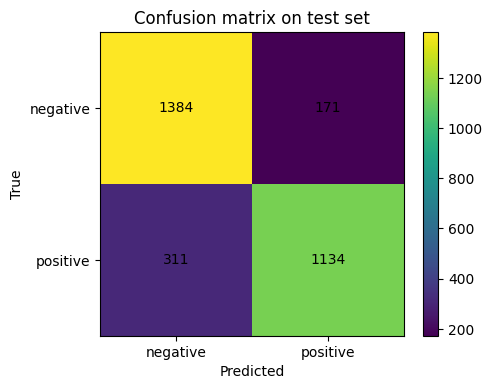

In [15]:
# Plot 5: BiLSTM validation vs test metrics
metrics = ["accuracy", "precision", "recall", "f1"]

val_values = [bilstm_val_metrics[m] for m in metrics]
test_values = [bilstm_test_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, val_values, width, label="Validation")
plt.bar(x + width/2, test_values, width, label="Test")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title("BiLSTM final metrics: validation vs test")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix trên test
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion matrix on test set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["negative", "positive"])
plt.yticks([0, 1], ["negative", "positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


## Demo prediction

In [16]:
def predict_sentiment(sentence, model=bilstm):
    model.eval()

    cleaned = clean_text(sentence)
    ids = encode_text(cleaned)

    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_id = int(np.argmax(probs))
    pred_label = label_names[pred_id]

    return {
        "sentence": sentence,
        "cleaned": cleaned,
        "prediction": pred_label,
        "negative_probability": float(probs[0]),
        "positive_probability": float(probs[1]),
    }

demo_sentence = "This movie was really touching and I enjoyed every minute of it."
predict_sentiment(demo_sentence)


{'sentence': 'This movie was really touching and I enjoyed every minute of it.',
 'cleaned': 'this movie was really touching and i enjoyed every minute of it',
 'prediction': 'positive',
 'negative_probability': 2.952664544864092e-06,
 'positive_probability': 0.9999970197677612}

In [17]:
my_sentence = "The story was boring and the acting was terrible."

predict_sentiment(my_sentence)


{'sentence': 'The story was boring and the acting was terrible.',
 'cleaned': 'the story was boring and the acting was terrible',
 'prediction': 'negative',
 'negative_probability': 0.9999874830245972,
 'positive_probability': 1.2480479199439287e-05}